# Sales Pipeline Analytics

## Project Objective

This project analyzes CRM sales pipeline data to evaluate pipeline health, conversion rates, sales performance, and forecast accuracy.

The goal is to generate actionable insights that can help sales leadership improve forecasting accuracy and pipeline management.

## Key Questions

1. What is the total pipeline value?
2. What are the conversion rates between sales stages?
3. Which sales reps generate the most revenue?
4. Where do deals stall in the pipeline?
5. What is the average sales cycle length?

# Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
accounts = pd.read_csv("../data/accounts.csv")
products = pd.read_csv("../data/products.csv")
sales_teams = pd.read_csv("../data/sales_teams.csv")
pipeline = pd.read_csv("../data/sales_pipeline.csv")

In [3]:
pipeline.head()
pipeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   opportunity_id  8800 non-null   object 
 1   sales_agent     8800 non-null   object 
 2   product         8800 non-null   object 
 3   account         7375 non-null   object 
 4   deal_stage      8800 non-null   object 
 5   engage_date     8300 non-null   object 
 6   close_date      6711 non-null   object 
 7   close_value     6711 non-null   float64
dtypes: float64(1), object(7)
memory usage: 550.1+ KB


# Data Cleaning

In [4]:
pipeline["engage_date"] = pd.to_datetime(pipeline["engage_date"])
pipeline["close_date"] = pd.to_datetime(pipeline["close_date"])

pipeline["sales_cycle_days"] = (
    pipeline["close_date"] - pipeline["engage_date"]
).dt.days

In [5]:
pipeline.drop_duplicates()
pipeline.isnull().sum()

opportunity_id         0
sales_agent            0
product                0
account             1425
deal_stage             0
engage_date          500
close_date          2089
close_value         2089
sales_cycle_days    2089
dtype: int64

In [6]:
pipeline["is_closed"] = pipeline["deal_stage"].isin(["Won", "Lost"])
pipeline["is_won"] = pipeline["deal_stage"] == "Won"

In [7]:
closed_deals = pipeline[pipeline["is_closed"]]
won_deals = pipeline[pipeline["deal_stage"] == "Won"]
won_deals["close_value"].sum()

10005534.0

In [8]:
pipeline["sales_cycle_days"] = (
    pipeline["close_date"] - pipeline["engage_date"]
).dt.days
pipeline.loc[pipeline["is_closed"], "sales_cycle_days"].describe()

count    6711.000000
mean       47.985397
std        41.057665
min         1.000000
25%         8.000000
50%        45.000000
75%        85.000000
max       138.000000
Name: sales_cycle_days, dtype: float64

In [9]:
pipeline = pipeline.dropna(subset=["engage_date"])

In [10]:
pipeline["account"] = pipeline["account"].fillna("Unknown")

## Missing Data Handling

Several fields contained missing values due to the nature of CRM pipeline data.

- `close_date` and `close_value` are missing for opportunities that have not yet closed.
- These records represent **open pipeline deals**, so they were retained for pipeline analysis.
- Sales cycle metrics were calculated only for closed deals.

Data cleaning steps performed:

- Rows missing `engage_date` were removed because the engagement date is required to calculate sales cycle duration.
- Missing `account` values were filled with "Unknown" to preserve records while enabling analysis.

# Pipeline Overview

Do we have enough pipeline to hit revenue targets?

In [12]:
stage_counts = pipeline["deal_stage"].value_counts()

In [14]:
pipeline_value = pipeline["close_value"].sum()
print("Total Pipeline Value:", pipeline_value)

Total Pipeline Value: 10005534.0


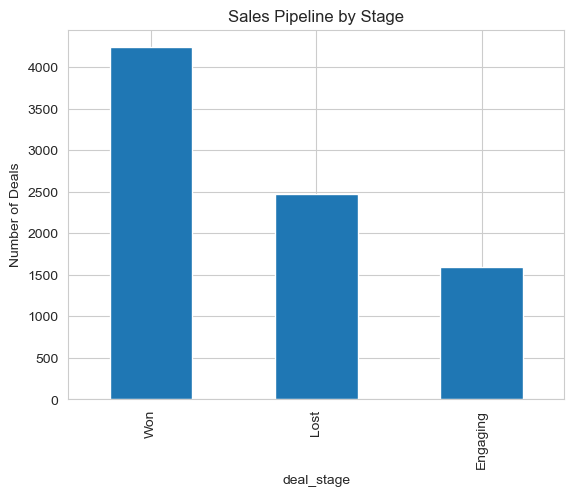

In [15]:
#Deals by stage
stage_counts = pipeline["deal_stage"].value_counts()

stage_counts.plot(kind="bar")
plt.title("Sales Pipeline by Stage")
plt.ylabel("Number of Deals")
plt.show()

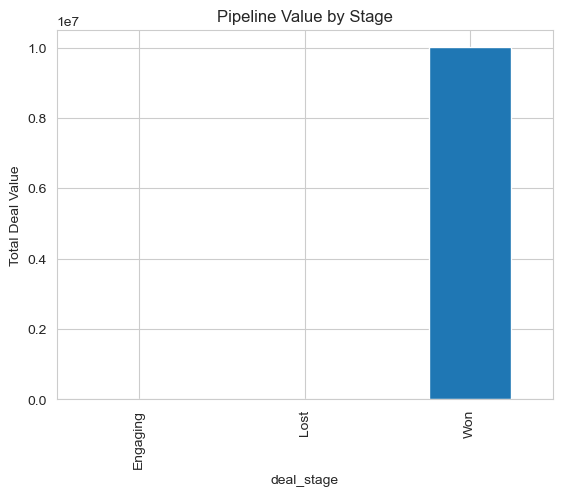

In [16]:
#Pipeline Value by stage
stage_value = pipeline.groupby("deal_stage")["close_value"].sum()

stage_value.plot(kind="bar")
plt.title("Pipeline Value by Stage")
plt.ylabel("Total Deal Value")
plt.show()

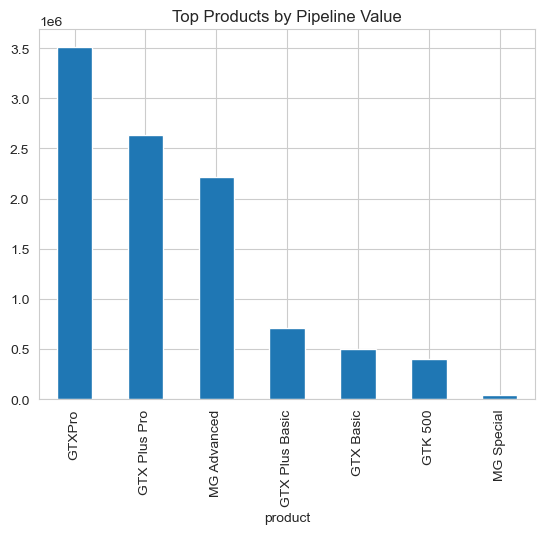

In [17]:
#Pipeline by product
product_pipeline = pipeline.groupby("product")["close_value"].sum().sort_values(ascending=False)

product_pipeline.head(10).plot(kind="bar")
plt.title("Top Products by Pipeline Value")
plt.show()

# Sales Rep Performance

Which reps drive the most revenue and close deals efficiently?

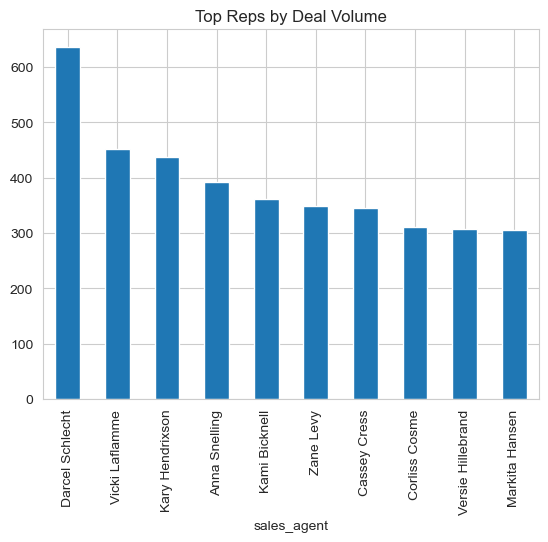

In [19]:
#Deals per rep
rep_deals = pipeline.groupby("sales_agent")["opportunity_id"].count()

rep_deals.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Reps by Deal Volume")
plt.show()

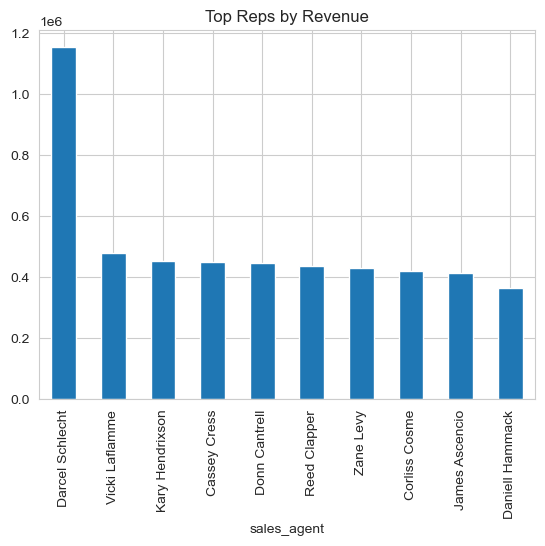

In [20]:
#Revenue per rep
rep_revenue = pipeline.groupby("sales_agent")["close_value"].sum()

rep_revenue.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Reps by Revenue")
plt.show()

How long does it take us to close deals?

In [21]:
#Average sales cycles
pipeline["sales_cycle_days"].mean()

47.98539710922366

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


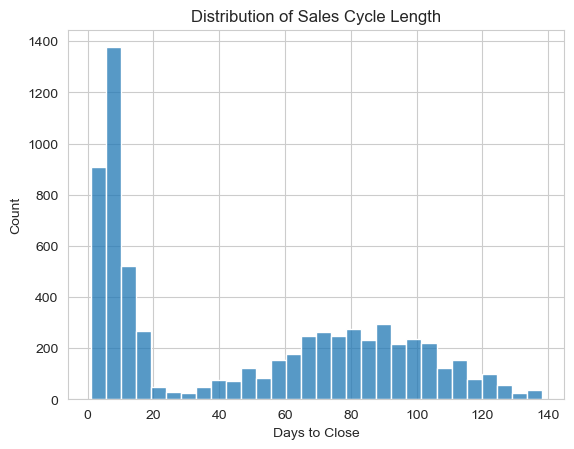

In [22]:
#Distribution of sales cycle
sns.histplot(pipeline["sales_cycle_days"], bins=30)

plt.title("Distribution of Sales Cycle Length")
plt.xlabel("Days to Close")
plt.show()

In [11]:
win_rate = (
    pipeline[pipeline["deal_stage"] == "Won"].shape[0] /
    pipeline[pipeline["is_closed"]].shape[0]
)

print("Win Rate:", round(win_rate * 100,2), "%")

Win Rate: 63.15 %


# Sales Cycle Analysis


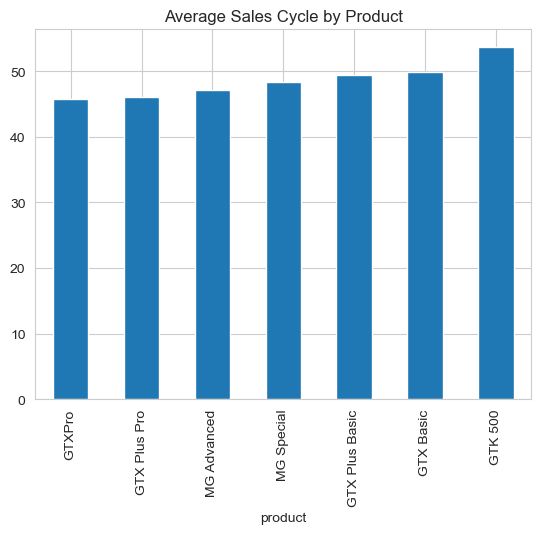

In [23]:
#Sale cycle by product
cycle_product = pipeline.groupby("product")["sales_cycle_days"].mean()

cycle_product.sort_values().head(10).plot(kind="bar")
plt.title("Average Sales Cycle by Product")
plt.show()

# Advanced Sales Analytics

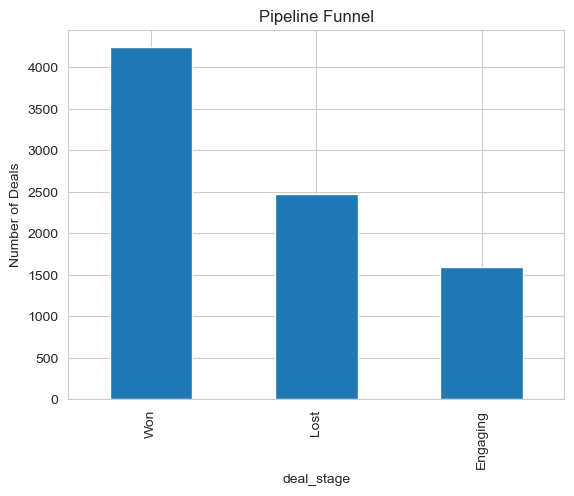

In [24]:
#Where are deals dropping off?
stage_conversion = pipeline["deal_stage"].value_counts()

stage_conversion.plot(kind="bar")

plt.title("Pipeline Funnel")
plt.ylabel("Number of Deals")
plt.show()

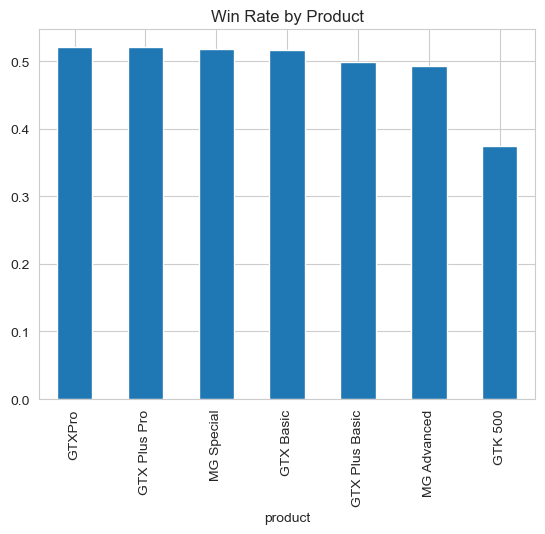

In [26]:
#Which products close most successfully?
product_win = pipeline.groupby("product")["is_won"].mean()

product_win.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Win Rate by Product")
plt.show()

In [27]:
#Revenue by Industry Sector
pipeline_accounts = pipeline.merge(accounts, on="account", how="left")

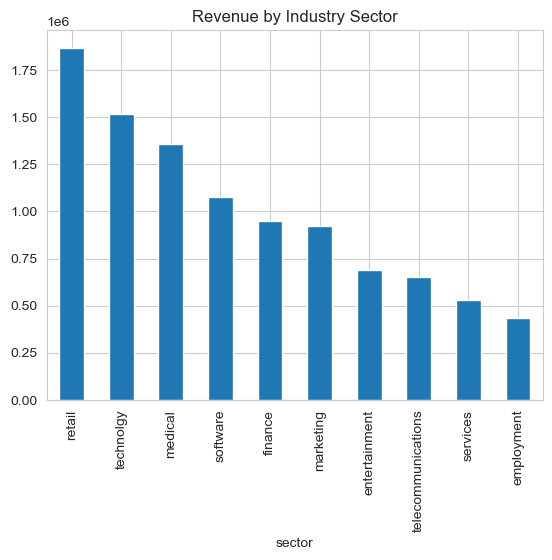

In [28]:
sector_revenue = pipeline_accounts.groupby("sector")["close_value"].sum()

sector_revenue.sort_values(ascending=False).plot(kind="bar")

plt.title("Revenue by Industry Sector")
plt.show()

In [29]:
#Revenue by Region
pipeline_region = pipeline.merge(sales_teams, on="sales_agent", how="left")

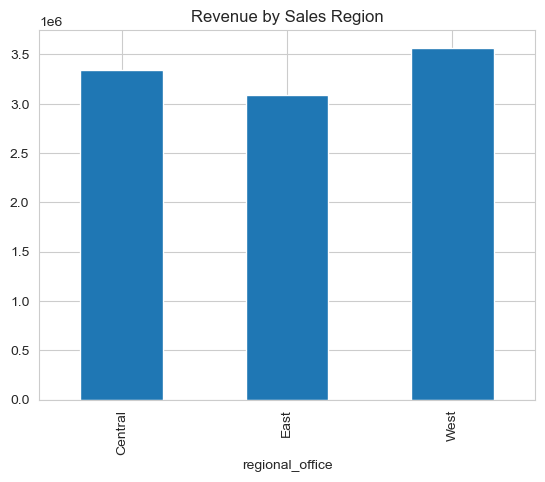

In [30]:
region_revenue = pipeline_region.groupby("regional_office")["close_value"].sum()

region_revenue.plot(kind="bar")

plt.title("Revenue by Sales Region")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


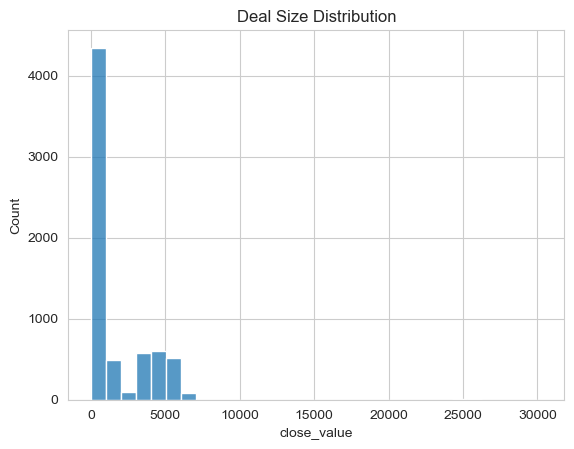

In [31]:
#What is the distribution of deal values?
sns.histplot(pipeline["close_value"], bins=30)

plt.title("Deal Size Distribution")
plt.show()

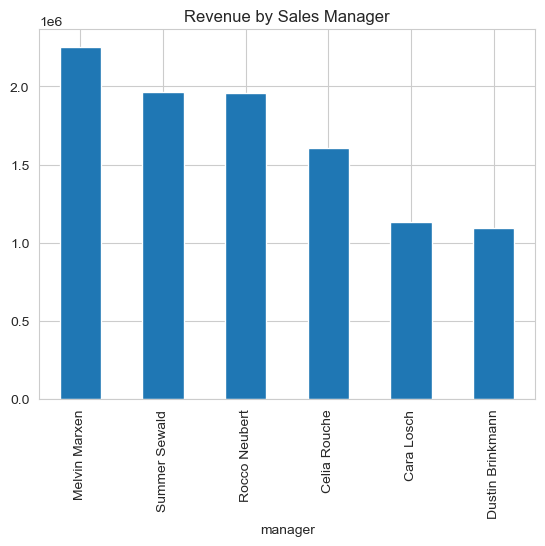

In [32]:
#Which teams perform best?
pipeline_manager = pipeline.merge(sales_teams, on="sales_agent", how="left")

manager_revenue = pipeline_manager.groupby("manager")["close_value"].sum()

manager_revenue.sort_values(ascending=False).plot(kind="bar")

plt.title("Revenue by Sales Manager")
plt.show()

# Key Insights

Key Insights

1. Pipeline concentration is highest in the negotiation stage, indicating potential deal bottlenecks.

2. Revenue generation is heavily concentrated among a small group of top-performing sales representatives.

3. Certain product lines demonstrate significantly higher win rates, suggesting strong product-market fit.

4. Sales cycles vary substantially by product, indicating opportunities to streamline the sales process.

5. Several industry sectors generate disproportionately high revenue, presenting opportunities for targeted sales strategies.